In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Configure display options
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 50)
sns.set_theme(style="whitegrid")

DATA_DIR = Path("../data/raw")

train_df = pd.read_csv(DATA_DIR / "train.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")

print(f"Train dimensions: {train_df.shape}")
print(f"Test dimensions:  {test_df.shape}")
print(f"Total missing values in train: {train_df.isna().sum().sum()}")
print(f"Total missing values in test:  {test_df.isna().sum().sum()}")

Train dimensions: (4209, 378)
Test dimensions:  (4209, 377)
Total missing values in train: 0
Total missing values in test:  0


In [2]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4209 entries, 0 to 4208
Columns: 378 entries, ID to X385
dtypes: float64(1), int64(369), str(8)
memory usage: 12.1 MB


In [3]:
train_df.head()

,ID,y,X0,X1,X2,X3,X4,X5,X6,X8,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23,X24,X26,X27,X28,X29,X30,X31,X32,X33,X34,X35,X36,X37,X38,X39,X40,X41,X42,X43,X44,X45,X46,X47,X48,X49,X50,...,X335,X336,X337,X338,X339,X340,X341,X342,X343,X344,X345,X346,X347,X348,X349,X350,X351,X352,X353,X354,X355,X356,X357,X358,X359,X360,X361,X362,X363,X364,X365,X366,X367,X368,X369,X370,X371,X372,X373,X374,X375,X376,X377,X378,X379,X380,X382,X383,X384,X385
0,0,130.81,k,v,at,a,d,u,j,o,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
1,6,88.53,k,t,av,e,d,y,l,o,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
2,7,76.26,az,w,n,c,d,x,j,x,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,1,0,1,0,0,0,1,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
3,9,80.62,az,t,n,f,d,x,l,e,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,1,0,0,0,1,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
4,13,78.02,az,v,n,f,d,h,d,n,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,1,0,0,0,1,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0


In [4]:
unique_values = {col: train_df[col].unique() for col in train_df.columns if col not in ["ID", "y"]}

unique_df = pd.DataFrame.from_dict(unique_values, orient='index')
unique_df.columns = [f'Unique value {i+1}' for i in range(unique_df.shape[1])]

from IPython.display import HTML, display

display(HTML(f"""
<div style="max-height: 400px; overflow-y: auto;">
{unique_df.to_html(max_rows=None)}
</div>
"""))

,Unique value 1,Unique value 2,Unique value 3,Unique value 4,Unique value 5,Unique value 6,Unique value 7,Unique value 8,Unique value 9,Unique value 10,Unique value 11,Unique value 12,Unique value 13,Unique value 14,Unique value 15,Unique value 16,Unique value 17,Unique value 18,Unique value 19,Unique value 20,Unique value 21,Unique value 22,Unique value 23,Unique value 24,Unique value 25,Unique value 26,Unique value 27,Unique value 28,Unique value 29,Unique value 30,Unique value 31,Unique value 32,Unique value 33,Unique value 34,Unique value 35,Unique value 36,Unique value 37,Unique value 38,Unique value 39,Unique value 40,Unique value 41,Unique value 42,Unique value 43,Unique value 44,Unique value 45,Unique value 46,Unique value 47
X0,k,az,t,al,o,w,j,h,s,n,ay,f,x,y,aj,ak,am,z,q,at,ap,v,af,a,e,ai,d,aq,c,aa,ba,as,i,r,b,ax,bc,u,ad,au,m,l,aw,ao,ac,g,ab
X1,v,t,w,b,r,l,s,aa,c,a,e,h,z,j,o,u,p,n,i,y,d,f,m,k,g,q,ab,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
X2,at,av,n,e,as,aq,r,ai,ak,m,a,k,ae,s,f,d,ag,ay,ac,ap,g,i,aw,y,b,ao,al,h,x,au,t,an,z,ah,p,am,j,q,af,l,aa,c,o,ar,NaN,NaN,NaN
X3,a,e,c,f,d,b,g,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
X4,d,b,c,a,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
X5,u,y,x,h,g,f,j,i,d,c,af,ag,ab,ac,ad,ae,ah,l,k,n,m,p,q,s,r,v,w,o,aa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
X6,j,l,d,h,i,a,g,c,k,e,f,b,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
X8,o,x,e,n,s,a,h,p,m,k,d,i,v,j,b,q,w,g,y,l,f,u,r,t,c,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
X10,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
X11,0,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
cat_cols = train_df.select_dtypes(include=["str"]).columns.tolist()
binary_cols = [c for c in train_df.columns if c not in cat_cols and c not in ["ID", "y"]]


In [6]:
cat_cols

['X0', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X8']

In [7]:
binary_cols

['X10',
 'X11',
 'X12',
 'X13',
 'X14',
 'X15',
 'X16',
 'X17',
 'X18',
 'X19',
 'X20',
 'X21',
 'X22',
 'X23',
 'X24',
 'X26',
 'X27',
 'X28',
 'X29',
 'X30',
 'X31',
 'X32',
 'X33',
 'X34',
 'X35',
 'X36',
 'X37',
 'X38',
 'X39',
 'X40',
 'X41',
 'X42',
 'X43',
 'X44',
 'X45',
 'X46',
 'X47',
 'X48',
 'X49',
 'X50',
 'X51',
 'X52',
 'X53',
 'X54',
 'X55',
 'X56',
 'X57',
 'X58',
 'X59',
 'X60',
 'X61',
 'X62',
 'X63',
 'X64',
 'X65',
 'X66',
 'X67',
 'X68',
 'X69',
 'X70',
 'X71',
 'X73',
 'X74',
 'X75',
 'X76',
 'X77',
 'X78',
 'X79',
 'X80',
 'X81',
 'X82',
 'X83',
 'X84',
 'X85',
 'X86',
 'X87',
 'X88',
 'X89',
 'X90',
 'X91',
 'X92',
 'X93',
 'X94',
 'X95',
 'X96',
 'X97',
 'X98',
 'X99',
 'X100',
 'X101',
 'X102',
 'X103',
 'X104',
 'X105',
 'X106',
 'X107',
 'X108',
 'X109',
 'X110',
 'X111',
 'X112',
 'X113',
 'X114',
 'X115',
 'X116',
 'X117',
 'X118',
 'X119',
 'X120',
 'X122',
 'X123',
 'X124',
 'X125',
 'X126',
 'X127',
 'X128',
 'X129',
 'X130',
 'X131',
 'X132',
 'X133',

## Target variable (`y`)

count    4209.000000
mean      100.669318
std        12.679381
min        72.110000
25%        90.820000
50%        99.150000
75%       109.010000
max       265.320000
Name: y, dtype: float64


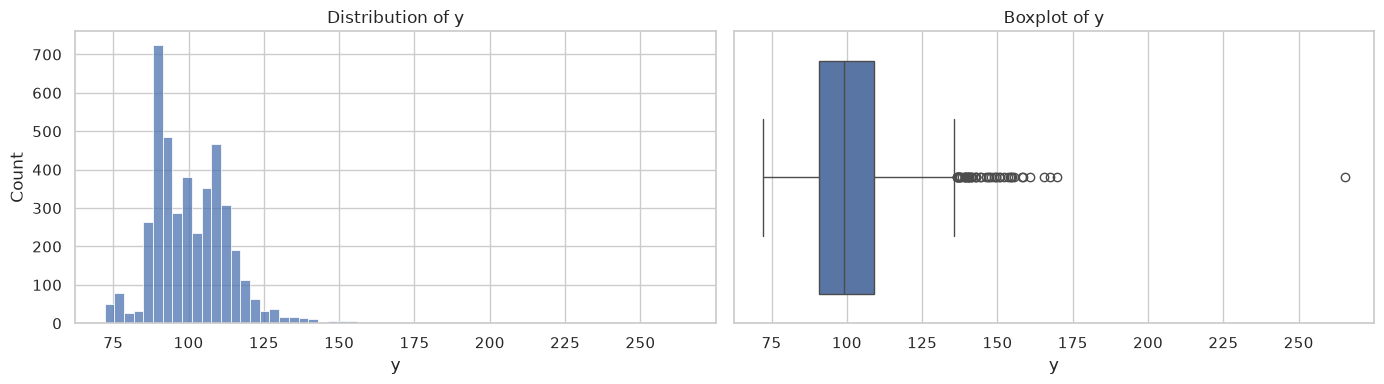


Rows with y > 200: 1


,ID,y
883,1770,265.32


In [8]:
print(train_df["y"].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(train_df["y"], bins=60, ax=axes[0])
axes[0].set_title("Distribution of y")
sns.boxplot(x=train_df["y"], ax=axes[1])
axes[1].set_title("Boxplot of y")
plt.tight_layout()
plt.show()

outlier_threshold = 200
outliers = train_df[train_df["y"] > outlier_threshold]
print(f"\nRows with y > {outlier_threshold}: {len(outliers)}")
outliers[["ID", "y"]]

## Categorical columns

In [9]:
cardinality = pd.DataFrame({
    "n_unique_train": [train_df[c].nunique() for c in cat_cols],
    "n_unique_test": [test_df[c].nunique() for c in cat_cols],
}, index=cat_cols)

unseen_counts = []
for c in cat_cols:
    train_levels = set(train_df[c].unique())
    test_levels = set(test_df[c].unique())
    unseen_counts.append(len(test_levels - train_levels))
cardinality["levels_in_test_not_in_train"] = unseen_counts

cardinality

,n_unique_train,n_unique_test,levels_in_test_not_in_train
X0,47,49,6
X1,27,27,0
X2,44,45,6
X3,7,7,0
X4,4,4,0
X5,29,32,4
X6,12,12,0
X8,25,25,0


## Binary columns: constant & duplicate features

In [10]:
constant_cols = [c for c in binary_cols if train_df[c].nunique() == 1]
print(f"Constant columns in train ({len(constant_cols)}): {constant_cols}")

non_constant_binary = [c for c in binary_cols if c not in constant_cols]
dup_groups = train_df[non_constant_binary].T.groupby(
    train_df[non_constant_binary].T.apply(tuple, axis=1)
).groups
duplicate_sets = [list(v) for v in dup_groups.values() if len(v) > 1]
duplicate_cols_to_drop = [c for group in duplicate_sets for c in group[1:]]

print(f"\nDuplicate column groups: {len(duplicate_sets)}")
print(f"Duplicate columns to drop (keeping first of each group): {len(duplicate_cols_to_drop)}")
for group in duplicate_sets:
    print(f"  {group}")

print(f"\nTotal columns to drop (constant + duplicate): {len(constant_cols) + len(duplicate_cols_to_drop)}")
print(f"Binary columns remaining after cleanup: {len(binary_cols) - len(constant_cols) - len(duplicate_cols_to_drop)}")

Constant columns in train (12): ['X11', 'X93', 'X107', 'X233', 'X235', 'X268', 'X289', 'X290', 'X293', 'X297', 'X330', 'X347']



Duplicate column groups: 28
Duplicate columns to drop (keeping first of each group): 45
  ['X33', 'X39']
  ['X298', 'X299']
  ['X60', 'X248', 'X253', 'X385']
  ['X295', 'X296']
  ['X89', 'X245']
  ['X53', 'X102', 'X214', 'X239']
  ['X88', 'X122', 'X243', 'X320']
  ['X90', 'X94', 'X242']
  ['X230', 'X254']
  ['X67', 'X213']
  ['X112', 'X199']
  ['X44', 'X302']
  ['X125', 'X227']
  ['X48', 'X113', 'X134', 'X147', 'X222']
  ['X62', 'X172', 'X216']
  ['X155', 'X360']
  ['X138', 'X146']
  ['X152', 'X226', 'X326']
  ['X240', 'X364', 'X365']
  ['X202', 'X247']
  ['X17', 'X382']
  ['X71', 'X84', 'X244']
  ['X29', 'X232', 'X279']
  ['X54', 'X76']
  ['X184', 'X262', 'X266']
  ['X58', 'X324']
  ['X118', 'X119']
  ['X31', 'X35', 'X37']

Total columns to drop (constant + duplicate): 57
Binary columns remaining after cleanup: 311


## Summary of Findings & Next Steps

### Dataset
- 4209 rows in both train and test, 378 columns in train (377 in test — no `y`)
- No missing values anywhere
- Columns: `ID`, `y` (target), 8 categorical (`X0,X1,X2,X3,X4,X5,X6,X8`), 368 binary flag columns
- **Gotcha (pandas 3.0):** string columns load as dtype `"str"`, not `"object"` — use `select_dtypes(include=["str"])`, not `dtype == "object"`, when detecting categoricals

### Target (`y`)
- Range ~72–160s for the bulk of the data, mean ≈ 100.7s, std ≈ 12.7s
- **One extreme outlier: `ID 1770`, `y = 265.32`** (~13 std devs above the mean)
- **Decision:** drop this row. **Resolved in `src/data.py::load_raw_data()`** — dropped from the raw training data before anything else happens, so every downstream notebook/model gets outlier-free data automatically.

### Categorical columns (`cat_cols`)
- Cardinality ranges from 4 (`X4`) to 47 (`X0`) unique levels
- **`X0`, `X2`, `X5` have category levels in test that never appear in train** (6, 6, 4 unseen levels respectively)
- **Instruction for feature engineering:** don't use an encoder that fails on unseen categories (e.g. plain `LabelEncoder`, or one-hot fit on train alone with `handle_unknown="error"`).
- **Resolved in `src/preprocessing.py::build_preprocessor()`** — the project settled on `OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)`, fit on `X_train` only (not joint train+test fitting, which would leak test-set category vocabulary into training). Ordinal rather than one-hot because cardinality up to 47 would make one-hot very wide, and tree-based models (the majority of what's evaluated in `03_model_comparison.ipynb`) don't assume any real order in the integer codes, so there's no downside to the arbitrary ordering ordinal encoding imposes.

### Binary columns (`binary_cols`)
- 368 total; **12 are constant** (`constant_cols` — zero variance, no signal) and **45 are exact duplicates of another column** (`duplicate_cols_to_drop`, 28 duplicate groups), computed here on the *full* `train_df`
- **Instruction:** drop `constant_cols + duplicate_cols_to_drop` (57 columns) before modeling → 311 clean binary features remain
- **Resolved in `src/preprocessing.py::find_columns_to_drop()`** — same constant/duplicate logic, but recomputed from `X_train` only (not the full `train_df` shown here), since a column being constant/duplicate across the full dataset doesn't guarantee it's still constant/duplicate within just the train split. In the actual 80/20 split used throughout the project, this drops 66 columns instead of 57 — expected, not a discrepancy.
- Consider dimensionality reduction (PCA/ICA/SVD/GRP/SRP) on the cleaned binary block — this was the differentiator in top solutions for this competition. **Not yet done** — open item, see `README.md`'s Next Steps.

### Baseline
- Predict-the-mean dummy model scores **R² ≈ 0.00 (5-fold CV, `random_state=42`)**
- Any real model must clear this floor by a wide margin to prove it's learning from the features
- **Reuse the same 5-fold CV split (`KFold(n_splits=5, shuffle=True, random_state=42)`) for every subsequent model** so scores stay comparable to this baseline and to each other — enforced by `src/preprocessing.py::get_cv_splitter()`

### Handoff to Feature Engineering — all resolved in `src/`, see `README.md` for the full pipeline writeup
1. ~~Drop the row/handle the outlier per the decision above~~ → `src/data.py::load_raw_data()`
2. ~~Drop `constant_cols` and `duplicate_cols_to_drop` from the binary feature set~~ → `src/preprocessing.py::find_columns_to_drop()`
3. ~~Encode `cat_cols` with an unseen-category-safe method~~ → `src/preprocessing.py::build_preprocessor()`
4. Apply dimensionality reduction to the binary block — **still open**
5. ~~Pass the resulting feature matrix to Modeling using the same CV split as this baseline~~ → `src/preprocessing.py::get_processed_data()` + `get_cv_splitter()`, used in `02_baseline_model.ipynb` and `03_model_comparison.ipynb`